In [1]:
import re
from yaml import safe_load
import datetime


from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr

from geopy.distance import distance
import geopandas as gpd

import echopype as ep

from core import GRID_PARAMS
from grid import create_boundary_gdf, create_grid_from_bounds
from flows_biology import add_stratum

from prefect import task, flow

In [2]:
# Load variables from config
with open("/Users/wujung/code_git/echodataflow/echodataflow/rewrite/config_cloud.yaml", "r") as file:
    config = safe_load(file)

In [3]:
from flows_biology import flow_ingest_haul

In [4]:
flow_ingest_haul(
    path_main=config["ingest_haul"]["path_main"],
    path_bio_files=config["ingest_haul"]["path_bio_files"],
    path_haul_info_all=config["ingest_haul"]["path_haul_info_all"],
    path_specimen_all=config["ingest_haul"]["path_specimen_all"],
    path_length_all=config["ingest_haul"]["path_length_all"],
    path_length_count_all=config["ingest_haul"]["path_length_count_all"],
    path_stratum_mean=config["ingest_haul"]["path_stratum_mean"],
)

In [ ]:
from flows_integration import (
    flow_ingest_NASC
)

In [ ]:
flow_ingest_NASC(
    path_main = config["ingest_NASC"]["path_main"],
    path_NASC_files = config["ingest_NASC"]["path_NASC_files"],
    path_NASC_all = config["ingest_NASC"]["path_NASC_all"],
    num_NASC_reprocess = 1,
)

No new NASC files to process.


In [ ]:
flow_ingest_NASC(
    path_main = config["ingest_NASC"]["path_main"],
    path_NASC_files = config["ingest_NASC"]["path_NASC_files"],
    path_NASC_all = config["ingest_NASC"]["path_NASC_all"],
    num_NASC_reprocess = 1,
)

Files to process:
 ['-', ' ', 'w', 'i', 'n', '_', '0', '0', '0', '2', '.', 'z', 'a', 'r', 'r', '\n']
Files to process:
- win_0002.zarr



In [ ]:
flow_ingest_NASC(
    path_main = config["ingest_NASC"]["path_main"],
    path_NASC_files = config["ingest_NASC"]["path_NASC_files"],
    path_NASC_all = config["ingest_NASC"]["path_NASC_all"],
    num_NASC_reprocess = 1,
)

Files to process:
 ['-', ' ', 'w', 'i', 'n', '_', '0', '0', '0', '1', '.', 'z', 'a', 'r', 'r', '\n', '-', ' ', 'w', 'i', 'n', '_', '0', '0', '0', '2', '.', 'z', 'a', 'r', 'r', '\n', '-', ' ', 'w', 'i', 'n', '_', '0', '0', '0', '3', '.', 'z', 'a', 'r', 'r', '\n', '-', ' ', 'w', 'i', 'n', '_', '0', '0', '0', '4', '.', 'z', 'a', 'r', 'r', '\n', '-', ' ', 'w', 'i', 'n', '_', '0', '0', '0', '5', '.', 'z', 'a', 'r', 'r', '\n']
Files to process:
- win_0001.zarr
- win_0002.zarr
- win_0003.zarr
- win_0004.zarr
- win_0005.zarr



In [ ]:
flow_ingest_NASC(
    path_main = config["ingest_NASC"]["path_main"],
    path_NASC_files = config["ingest_NASC"]["path_NASC_files"],
    path_NASC_all = config["ingest_NASC"]["path_NASC_all"],
    num_NASC_reprocess = 1,
)

Files to process:
 ['-', ' ', 'w', 'i', 'n', '_', '0', '0', '0', '5', '.', 'z', 'a', 'r', 'r', '\n', '-', ' ', 'w', 'i', 'n', '_', '0', '0', '0', '6', '.', 'z', 'a', 'r', 'r', '\n', '-', ' ', 'w', 'i', 'n', '_', '0', '0', '0', '7', '.', 'z', 'a', 'r', 'r', '\n', '-', ' ', 'w', 'i', 'n', '_', '0', '0', '0', '8', '.', 'z', 'a', 'r', 'r', '\n']
Files to process:
- win_0005.zarr
- win_0006.zarr
- win_0007.zarr
- win_0008.zarr



In [11]:
a = []

In [12]:
a[:-1]

[]

In [13]:
pd.read_csv(Path(config["ingest_NASC"]["path_main"]) / "NASC_all_grid.csv", index_col=0)

,NASC,channel,frequency_nominal,latitude,longitude,ping_time,filename,geometry,utm_x,utm_y,grid_x,grid_y,stratum
0,0.0,WBT 400143-15 ES38B_ES,38000.0,39.280826,-124.929718,2024-07-07 18:06:40.000000000,win_0001.zarr,POINT (851114.4849549241 4355844.275234469),851114.484955,4.355844e+06,21,16,2
1,0.0,WBT 400143-15 ES38B_ES,38000.0,39.273865,-124.924258,2024-07-07 18:09:22.500000000,win_0001.zarr,POINT (851620.5126066771 4355092.589156238),851620.512607,4.355093e+06,21,16,2
2,0.0,WBT 400143-15 ES38B_ES,38000.0,39.266657,-124.918675,2024-07-07 18:12:07.500000000,win_0001.zarr,POINT (852138.4352946078 4354314.042926684),852138.435295,4.354314e+06,21,16,2
3,0.0,WBT 400143-15 ES38B_ES,38000.0,39.259561,-124.913200,2024-07-07 18:14:50.000000000,win_0001.zarr,POINT (852646.6258188225 4353547.540112513),852646.625819,4.353548e+06,21,16,2
4,0.0,WBT 400143-15 ES38B_ES,38000.0,39.252463,-124.907738,2024-07-07 18:17:30.000000000,win_0001.zarr,POINT (853153.7667520302 4352780.717980591),853153.766752,4.352781e+06,21,16,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
138,0.0,WBT 400143-15 ES38B_ES,38000.0,38.938913,-124.668718,2024-07-07 20:13:52.500000,win_0009.zarr,POINT (875451.3171783017 4318926.250684156),875451.317178,4.318926e+06,21,15,2
139,0.0,WBT 400143-15 ES38B_ES,38000.0,38.931098,-124.663204,2024-07-07 20:16:45,win_0009.zarr,POINT (875970.8432784441 4318081.260926172),875970.843278,4.318081e+06,21,15,2
140,0.0,WBT 400143-15 ES38B_ES,38000.0,38.924050,-124.658067,2024-07-07 20:19:22.500000,win_0009.zarr,POINT (876453.7308604219 4317319.841046722),876453.730860,4.317320e+06,21,15,2
141,0.0,WBT 400143-15 ES38B_ES,38000.0,38.916990,-124.652268,2024-07-07 20:22:02.500000,win_0009.zarr,POINT (876994.1096265715 4316559.98312081),876994.109627,4.316560e+06,21,15,2


In [14]:
gdf_NASC = gpd.read_file(Path(config["ingest_NASC"]["path_main"]) / "NASC_all_griddify.geojson")

In [15]:
gdf_NASC

,NASC,channel,frequency_nominal,latitude,longitude,ping_time,filename,utm_x,utm_y,grid_x,grid_y,stratum,geometry
0,0.000000,WBT 400143-15 ES38B_ES,38000.0,39.280826,-124.929718,2024-07-07 18:06:40.000,win_0001.zarr,851114.484955,4.355844e+06,21,16,2,POINT (851114.485 4355844.275)
1,0.000000,WBT 400143-15 ES38B_ES,38000.0,39.273865,-124.924258,2024-07-07 18:09:22.500,win_0001.zarr,851620.512607,4.355093e+06,21,16,2,POINT (851620.513 4355092.589)
2,0.000000,WBT 400143-15 ES38B_ES,38000.0,39.266657,-124.918675,2024-07-07 18:12:07.500,win_0001.zarr,852138.435295,4.354314e+06,21,16,2,POINT (852138.435 4354314.043)
3,0.000000,WBT 400143-15 ES38B_ES,38000.0,39.259561,-124.913200,2024-07-07 18:14:50.000,win_0001.zarr,852646.625819,4.353548e+06,21,16,2,POINT (852646.626 4353547.54)
4,0.000000,WBT 400143-15 ES38B_ES,38000.0,39.252463,-124.907738,2024-07-07 18:17:30.000,win_0001.zarr,853153.766752,4.352781e+06,21,16,2,POINT (853153.767 4352780.718)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.995562,-124.710488,2024-07-07 19:53:20.000,win_0006.zarr,871532.380378,4.325045e+06,21,15,2,POINT (871532.38 4325044.661)
91,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.988363,-124.705165,2024-07-07 19:55:57.500,win_0006.zarr,872031.357275,4.324267e+06,21,15,2,POINT (872031.357 4324267.159)
92,125.093777,WBT 400143-15 ES38B_ES,38000.0,38.981051,-124.699876,2024-07-07 19:58:35.000,win_0006.zarr,872528.116500,4.323477e+06,21,15,2,POINT (872528.117 4323476.926)
93,234.416940,WBT 400143-15 ES38B_ES,38000.0,38.973949,-124.694599,2024-07-07 20:01:10.000,win_0006.zarr,873022.783137,4.322710e+06,21,15,2,POINT (873022.783 4322709.936)


In [18]:
gdf_grid_cells, gdf_coastline, _ = create_grid_from_bounds(
    bounds=GRID_PARAMS["bounds"], 
    resolution=GRID_PARAMS["resolution"],
    projection=GRID_PARAMS["projection"],
    coastline_resolution="10m",
    area_threshold=5
)
gdf_grid_cells.set_index(["grid_x", "grid_y"], inplace=True)


In [21]:
gdf_grid_cells.to_file(
    Path(config["ingest_NASC"]["path_main"]) / "test.geojson",
    driver="GeoJSON"
)

In [23]:
gdf_grid_cells.reset_index().to_file(
    Path(config["ingest_NASC"]["path_main"]) / "test_reset_index.geojson",
    driver="GeoJSON"
)

In [31]:
import configparser, s3fs

In [25]:
cred_file = "/Users/wujung/.config/rclone/rclone.conf"
config = configparser.ConfigParser()
config.read(cred_file)

['/Users/wujung/.config/rclone/rclone.conf']

In [30]:
config["osn_sdsc_hake"]["access_key_id"], config["osn_sdsc_hake"]["endpoint"]

('QT1Z9P89ORP7VZCLNI42', 'https://sdsc.osn.xsede.org')

In [33]:
fs = s3fs.S3FileSystem(
    key=config["osn_sdsc_hake"]["access_key_id"],
    secret=config["osn_sdsc_hake"]["secret_access_key"],
    endpoint_url=config["osn_sdsc_hake"]["endpoint"],
)

In [42]:
fs.glob("agr230002-bucket01/prefect_test/test*")

['agr230002-bucket01/prefect_test/test1',
 'agr230002-bucket01/prefect_test/test2',
 'agr230002-bucket01/prefect_test/test3',
 'agr230002-bucket01/prefect_test/test4',
 'agr230002-bucket01/prefect_test/test5']

In [43]:
fs.glob("agr230002-bucket01/prefect_test/test2/*.csv")

['agr230002-bucket01/prefect_test/test2/SH2306_MVBS_files.csv',
 'agr230002-bucket01/prefect_test/test2/SH2306_Sv_files.csv',
 'agr230002-bucket01/prefect_test/test2/SH2306_prediction_files.csv']

In [55]:
fs.glob("agr230002-bucket01/prefect_test/temp_bio/nasc_zarr/*")

['agr230002-bucket01/prefect_test/temp_bio/nasc_zarr/.DS_Store',
 'agr230002-bucket01/prefect_test/temp_bio/nasc_zarr/win_0001.zarr',
 'agr230002-bucket01/prefect_test/temp_bio/nasc_zarr/win_0002.zarr',
 'agr230002-bucket01/prefect_test/temp_bio/nasc_zarr/win_0003.zarr',
 'agr230002-bucket01/prefect_test/temp_bio/nasc_zarr/win_0004.zarr',
 'agr230002-bucket01/prefect_test/temp_bio/nasc_zarr/win_0005.zarr',
 'agr230002-bucket01/prefect_test/temp_bio/nasc_zarr/win_0006.zarr']

In [56]:
fs.glob("agr230002-bucket01/prefect_test/temp_bio/nasc_zarr/*/")

['agr230002-bucket01/prefect_test/temp_bio/nasc_zarr/win_0001.zarr',
 'agr230002-bucket01/prefect_test/temp_bio/nasc_zarr/win_0002.zarr',
 'agr230002-bucket01/prefect_test/temp_bio/nasc_zarr/win_0003.zarr',
 'agr230002-bucket01/prefect_test/temp_bio/nasc_zarr/win_0004.zarr',
 'agr230002-bucket01/prefect_test/temp_bio/nasc_zarr/win_0005.zarr',
 'agr230002-bucket01/prefect_test/temp_bio/nasc_zarr/win_0006.zarr']

In [59]:
bio_files = fs.glob("agr230002-bucket01/prefect_test/temp_bio/bio_csv/*.csv")
bio_files

['agr230002-bucket01/prefect_test/temp_bio/bio_csv/202407_003_catch_perc.csv',
 'agr230002-bucket01/prefect_test/temp_bio/bio_csv/202407_003_operation_info.csv',
 'agr230002-bucket01/prefect_test/temp_bio/bio_csv/202407_011_catch_perc.csv',
 'agr230002-bucket01/prefect_test/temp_bio/bio_csv/202407_011_operation_info.csv',
 'agr230002-bucket01/prefect_test/temp_bio/bio_csv/202407_036_catch_perc.csv',
 'agr230002-bucket01/prefect_test/temp_bio/bio_csv/202407_036_operation_info.csv',
 'agr230002-bucket01/prefect_test/temp_bio/bio_csv/202407_22500_003_lf.csv',
 'agr230002-bucket01/prefect_test/temp_bio/bio_csv/202407_22500_003_spec.csv',
 'agr230002-bucket01/prefect_test/temp_bio/bio_csv/202407_22500_011_lf.csv',
 'agr230002-bucket01/prefect_test/temp_bio/bio_csv/202407_22500_011_spec.csv',
 'agr230002-bucket01/prefect_test/temp_bio/bio_csv/202407_22500_036_lf.csv',
 'agr230002-bucket01/prefect_test/temp_bio/bio_csv/202407_22500_036_spec.csv']

In [58]:
fs.glob("agr230002-bucket01/prefect_test/temp_bio/bio_csv/*/")

[]

In [60]:
with fs.open(bio_files[0]) as f:
    df_test = pd.read_csv(f, index_col=0).reset_index()

In [61]:
df_test

,operation_number,partition,species_code,species,overall_count,overall_weight,catch_perc
0,3,Codend,22500.0,Pacific hake - Merluccius productus,1147,116.660,99.75
1,3,Codend,98072.0,Rabbit-eared Salp - Thetys vagina,1,0.100,0.09
2,3,Codend,23915.0,Medusafish - Icichthys lockingtoni,3,0.074,0.06
3,3,Codend,98003.0,Green colonial tunicate - Pyrosoma,15,0.041,0.04
4,3,Codend,20610.0,Northern anchovy - Engraulis mordax,2,0.040,0.03
5,3,Codend,40500.0,Jellyfish unident - Scyphozoa,0,0.020,0.02
6,3,Codend,98070.0,Salps family - Thaliacea,0,0.010,0.01
7,3,Codend,22610.0,California headlightfish - Diaphus theta,1,0.005,0.00
8,3,Pocket 10,22500.0,Pacific hake - Merluccius productus,1,0.080,88.89
9,3,Pocket 10,22610.0,California headlightfish - Diaphus theta,1,0.010,11.11


In [63]:
path_bio_files = "agr230002-bucket01/prefect_test/temp_bio/bio_csv"

In [64]:
date_prefix = "202407"
species_code = "22500"
bio_filenames = {
    "length": fs.glob(f"{path_bio_files}/{date_prefix}_{species_code}_*_lf.csv"),
    "specimen": fs.glob(f"{path_bio_files}/{date_prefix}_{species_code}_*_spec.csv"),
    "catch": fs.glob(f"{path_bio_files}/{date_prefix}_*_catch_perc.csv"),
    "info": fs.glob(f"{path_bio_files}/{date_prefix}_*_operation_info.csv"),
}


In [65]:
bio_filenames

{'length': ['agr230002-bucket01/prefect_test/temp_bio/bio_csv/202407_22500_003_lf.csv',
  'agr230002-bucket01/prefect_test/temp_bio/bio_csv/202407_22500_011_lf.csv',
  'agr230002-bucket01/prefect_test/temp_bio/bio_csv/202407_22500_036_lf.csv'],
 'specimen': ['agr230002-bucket01/prefect_test/temp_bio/bio_csv/202407_22500_003_spec.csv',
  'agr230002-bucket01/prefect_test/temp_bio/bio_csv/202407_22500_011_spec.csv',
  'agr230002-bucket01/prefect_test/temp_bio/bio_csv/202407_22500_036_spec.csv'],
 'catch': ['agr230002-bucket01/prefect_test/temp_bio/bio_csv/202407_003_catch_perc.csv',
  'agr230002-bucket01/prefect_test/temp_bio/bio_csv/202407_011_catch_perc.csv',
  'agr230002-bucket01/prefect_test/temp_bio/bio_csv/202407_036_catch_perc.csv'],
 'info': ['agr230002-bucket01/prefect_test/temp_bio/bio_csv/202407_003_operation_info.csv',
  'agr230002-bucket01/prefect_test/temp_bio/bio_csv/202407_011_operation_info.csv',
  'agr230002-bucket01/prefect_test/temp_bio/bio_csv/202407_036_operation_inf

In [66]:
df_length = []
for haul_num in [3, 11, 36]:
    with fs.open(f"{path_bio_files}/{date_prefix}_{species_code}_{haul_num:03d}_lf.csv") as f:
        df_length.append(pd.read_csv(f, index_col=0).reset_index())


In [69]:
from core import INFO_DATAFRAME_MAPPING

In [70]:
# Load dataframes from all hauls to process
df_length = []
df_specimen = []
df_info = []
for haul_num in [3, 11, 36]:
    with fs.open(f"{path_bio_files}/{date_prefix}_{species_code}_{haul_num:03d}_lf.csv") as f:
        df_length.append(pd.read_csv(f, index_col=0).reset_index())
    with fs.open(f"{path_bio_files}/{date_prefix}_{species_code}_{haul_num:03d}_spec.csv") as f:
        df_specimen.append(pd.read_csv(f, index_col=0).reset_index())
    with fs.open(f"{path_bio_files}/{date_prefix}_{haul_num:03d}_operation_info.csv") as f:
        df_info.append(
            # reset index to get operation_number into a column
            pd.read_csv(f, index_col=0).reset_index()
            .rename(columns=INFO_DATAFRAME_MAPPING).reset_index()
        )
df_length = pd.concat(df_length, ignore_index=True)
df_specimen = pd.concat(df_specimen, ignore_index=True)
df_info = pd.concat(df_info, ignore_index=True)


In [71]:
df_info

,index,operation_number,timestamp,latitude,longitude
0,0,3,20240709002246,37.155009,-122.754236
1,0,11,20240712000333,37.160085,-122.833601
2,0,36,20240725175637,37.165607,-122.764851


In [2]:
import s3fs, configparser

In [3]:
cred_file = "/Users/wujung/.config/rclone/rclone.conf"

config = configparser.ConfigParser()
config.read(cred_file)
fs = s3fs.S3FileSystem(
    key=config["osn_sdsc_hake"]["access_key_id"],
    secret=config["osn_sdsc_hake"]["secret_access_key"],
    endpoint_url=config["osn_sdsc_hake"]["endpoint"],
)

In [6]:
fs.glob("agr230002-bucket01/prefect_test/temp_bio/nasc_zarr/*.zarr")

['agr230002-bucket01/prefect_test/temp_bio/nasc_zarr/win_0001.zarr',
 'agr230002-bucket01/prefect_test/temp_bio/nasc_zarr/win_0002.zarr',
 'agr230002-bucket01/prefect_test/temp_bio/nasc_zarr/win_0003.zarr',
 'agr230002-bucket01/prefect_test/temp_bio/nasc_zarr/win_0004.zarr',
 'agr230002-bucket01/prefect_test/temp_bio/nasc_zarr/win_0005.zarr',
 'agr230002-bucket01/prefect_test/temp_bio/nasc_zarr/win_0006.zarr']

In [11]:
import xarray as xr
from pathlib import Path

In [15]:
path_NASC_files = "agr230002-bucket01/prefect_test/temp_bio/nasc_zarr"
nascf = "win_0001.zarr"

In [16]:
mapper = fs.get_mapper(str(Path(path_NASC_files) / nascf))
ds = xr.open_zarr(mapper, consolidated=True)

In [17]:
ds

<xarray.Dataset> Size: 50kB
Dimensions:            (channel: 5, distance: 16, depth: 76)
Coordinates:
  * channel            (channel) <U25 500B 'WBT 400140-15 ES120-7C_ES' ... 'W...
  * depth              (depth) float64 608B 0.0 10.0 20.0 ... 730.0 740.0 750.0
  * distance           (distance) float64 128B 0.0 0.5 1.0 1.5 ... 6.5 7.0 7.5
Data variables:
    NASC               (channel, distance, depth) float64 49kB dask.array<chunksize=(5, 16, 76), meta=np.ndarray>
    frequency_nominal  (channel) float64 40B dask.array<chunksize=(5,), meta=np.ndarray>
    latitude           (distance) float64 128B dask.array<chunksize=(16,), meta=np.ndarray>
    longitude          (distance) float64 128B dask.array<chunksize=(16,), meta=np.ndarray>
    ping_time          (distance) datetime64[ns] 128B dask.array<chunksize=(16,), meta=np.ndarray>
Attributes:
    Conventions:           CF-1.7,ACDD-1.3
    geospatial_lat_max:    39.28427
    geospatial_lat_min:    39.17482
    geospatial_lon_max:    -124.84766
    geospatial_lon_min:    -124.93242
    processing_level:      Level 4
    processing_level_url:  https://echopype.readthedocs.io/en/stable/processi...
    time_coverage_end:     2024-07-07T18:47:00.000000000Z
    time_coverage_start:   2024-07-07T18:05:20.000000000Z

In [19]:
NASC_all = fs.glob(f"{path_NASC_files}/*.zarr")
NASC_all

['agr230002-bucket01/prefect_test/temp_bio/nasc_zarr/win_0001.zarr',
 'agr230002-bucket01/prefect_test/temp_bio/nasc_zarr/win_0002.zarr',
 'agr230002-bucket01/prefect_test/temp_bio/nasc_zarr/win_0003.zarr',
 'agr230002-bucket01/prefect_test/temp_bio/nasc_zarr/win_0004.zarr',
 'agr230002-bucket01/prefect_test/temp_bio/nasc_zarr/win_0005.zarr',
 'agr230002-bucket01/prefect_test/temp_bio/nasc_zarr/win_0006.zarr']

In [22]:
NASC_all = sorted([Path(f).name for f in NASC_all])
NASC_all

['win_0001.zarr',
 'win_0002.zarr',
 'win_0003.zarr',
 'win_0004.zarr',
 'win_0005.zarr',
 'win_0006.zarr']

In [23]:
import geopandas as gpd

In [26]:
from yaml import safe_load

In [27]:
# Load variables from config
with open("/Users/wujung/code_git/echodataflow/echodataflow/rewrite/config_cloud.yaml", "r") as file:
    config_cloud = safe_load(file)

In [38]:
gdf_grid_cells = gpd.read_file(
    Path(config_cloud["ingest_NASC"]["path_main"]) / "grid_cells.geojson"
)

In [39]:
gdf_grid_cells

,grid_x,grid_y,area,number_density,biomass_density,abundance,biomass,geometry
0,38,1,491.943240,NaN,NaN,NaN,NaN,"POLYGON ((-117.25452 32.76713, -117.25388 32.7..."
1,37,1,625.000000,NaN,NaN,NaN,NaN,"POLYGON ((-117.4894 32.78924, -117.49448 32.75..."
2,36,1,610.460377,NaN,NaN,NaN,NaN,"POLYGON ((-118.44992 32.81882, -118.43837 32.8..."
3,35,1,620.304729,NaN,NaN,NaN,NaN,"POLYGON ((-118.51361 32.88037, -118.5086 32.87..."
4,34,1,625.000000,NaN,NaN,NaN,NaN,"POLYGON ((-118.94753 32.9164, -118.96635 32.75..."
...,...,...,...,...,...,...,...,...
1165,5,53,625.000000,NaN,NaN,NaN,NaN,"POLYGON ((-135.24446 54.8394, -135.18116 54.42..."
1166,6,53,625.000000,NaN,NaN,NaN,NaN,"POLYGON ((-134.52703 54.87429, -134.47091 54.4..."
1167,5,54,625.000000,NaN,NaN,NaN,NaN,"POLYGON ((-135.24446 54.8394, -135.25 54.83909..."
1168,6,54,625.000000,NaN,NaN,NaN,NaN,"POLYGON ((-134.58461 55.2884, -134.52703 54.87..."


In [30]:
import matplotlib.pyplot as plt

In [35]:
from grid import create_grid_from_bounds

In [40]:
# Define grid boundary via longitude and latitude coordinates [minimum, maximum]
bounds = {
    "latitude": [32.75, 55.50],
    "longitude": [-135.25, -117.00]
}

# Define grid the resolution in the x- and y-directions in units nmi
grid_resolution = {
    "x_distance": 25.0,
    "y_distance": 25.0
}

# Define EPSG coordinate projection (latitude/longitude)
projection = "epsg:4326"

# Create the full grid
gdf_grid_cells_default, gdf_coastline, gdf_boundary = create_grid_from_bounds(
    bounds=bounds, 
    resolution=grid_resolution,
    projection=projection,
    coastline_resolution="10m",
    area_threshold=5
)

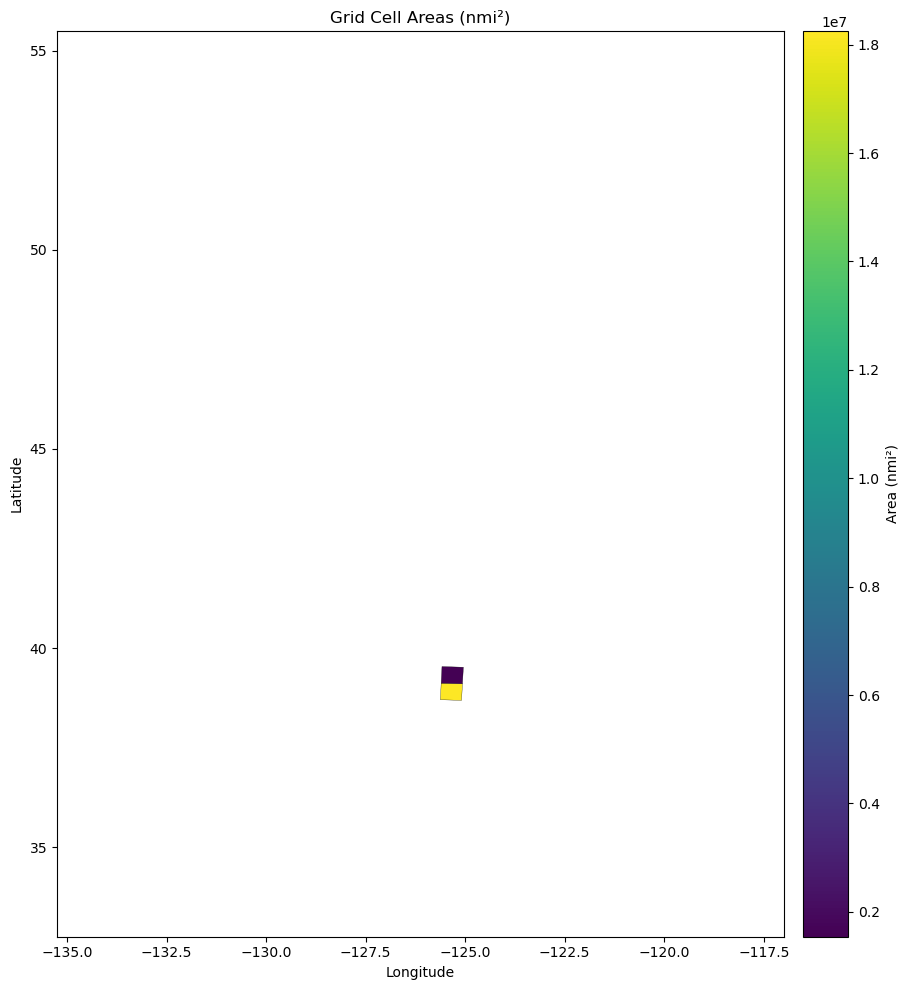

In [42]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot cells with area color
plot = gdf_grid_cells.plot(
    column="biomass", 
    ax=ax, 
    legend=False, 
    cmap="viridis", 
    edgecolor='k', 
    linewidth=0.2, 
    markersize=0
)

# Add colorbar with proper spacing
cbar = fig.colorbar(plot.get_children()[0], ax=ax, pad=0.02)
cbar.set_label('Area (nmi²)')

# Plot coastline if provided
if gdf_coastline is not None:
    gdf_coastline.plot(
        ax=ax, 
        color='lightgray', 
        edgecolor='black', 
        linewidth=0.5, 
        label='Coastline'
    )

# Plot boundary if provided
if gdf_boundary is not None:
    # Set plot limits to boundary
    if hasattr(gdf_boundary.geometry.iloc[0], 'bounds'):
        bounds = gdf_boundary.geometry.iloc[0].bounds
        ax.set_xlim(bounds[0], bounds[2])
        ax.set_ylim(bounds[1], bounds[3])

# Add labels and title
plt.title("Grid Cell Areas (nmi²)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Adjust layout to ensure nothing is cropped
plt.tight_layout()